In [1]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from tscglue import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tempfile
import boto3
import polars as pl
from tqdm import tqdm
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

In [3]:
def load_s3_parquet_cached(
    s3_prefix: str = "s3://tsc-glue/performance-benchmarking/",
    max_workers: int = 16,
) -> pl.DataFrame:

    cache_dir = os.path.join(tempfile.gettempdir(), "tsc-glue-cache")
    os.makedirs(cache_dir, exist_ok=True)

    parsed = urlparse(s3_prefix)
    bucket = parsed.netloc
    prefix = parsed.path.lstrip("/")

    s3 = boto3.client("s3")

    local_files = {
        f for f in os.listdir(cache_dir) if f.endswith(".parquet")
    }

    paginator = s3.get_paginator("list_objects_v2")
    remote_keys = []

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith(".parquet"):
                fname = key.rsplit("/", 1)[-1]
                if fname not in local_files:
                    remote_keys.append(key)

    def _download(key):
        fname = key.rsplit("/", 1)[-1]
        s3.download_file(
            bucket,
            key,
            os.path.join(cache_dir, fname),
        )

    if remote_keys:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(_download, k) for k in remote_keys]
            for _ in tqdm(as_completed(futures), total=len(futures)):
                pass

    local_paths = sorted(
        os.path.join(cache_dir, f)
        for f in os.listdir(cache_dir)
        if f.endswith(".parquet")
    )

    return pl.read_parquet(local_paths)

res_mine = load_s3_parquet_cached()#.filter(pl.col('fold')==0)
res_mine

100%|██████████| 6/6 [00:00<00:00, 12.94it/s]


dataset,model,fold,test_accuracy
str,str,i64,f64
"""PigArtPressure""","""multirocket-f32""",20,0.927885
"""BirdChicken""","""loky-stacker-v7-soft-rf""",0,0.9
"""RefrigerationDevices""","""loky-stacker-v8-base-r1""",22,0.786667
"""CricketY""","""loky-stacker-v10-base-r3""",0,0.869231
"""DistalPhalanxTW""","""loky-stacker-v10-tabicl""",21,0.690647
…,…,…,…
"""CricketZ""","""loky-stacker-v8-base-r3""",6,0.882051
"""ProximalPhalanxOutlineAgeGroup""","""loky-stacker-v9-base-r2""",12,0.858537
"""GunPointMaleVersusFemale""","""loky-stacker-v8-auto-best""",10,1.0


In [4]:
res_mine = res_mine.filter(
    (pl.col("model").str.contains("loky-stacker-v5"))==False
)

In [5]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [6]:
v = res_mine.filter(pl.col('fold')==5).pivot(values="test_accuracy", index="dataset", on="model").select(['dataset', 'loky-stacker-v7', 'loky-stacker-v6'])
v.with_columns((pl.col('loky-stacker-v7') - pl.col('loky-stacker-v6')).alias('diff')).sort('diff', descending=True)

dataset,loky-stacker-v7,loky-stacker-v6,diff
str,f64,f64,f64
"""CinCECGTorso""",0.999275,0.999275,0.0
"""ECG200""",0.9,0.9,0.0
"""Crop""",0.789107,0.789107,0.0
"""SemgHandSubjectCh2""",0.942222,0.942222,0.0
"""Beef""",0.633333,0.633333,0.0
…,…,…,…
"""Herring""",0.59375,0.59375,0.0
"""UWaveGestureLibraryX""",0.883585,0.883585,0.0
"""BirdChicken""",1.0,1.0,0.0


In [7]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,multirocket-f32,loky-stacker-v7-soft-rf,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multirocket-f16,mr-hydra-contained-auto,mr-hydra-kbest-5000,mycatch22v2,mycatch22,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v10-fm,loky-stacker-v6-soft-et,tabicl,multirocket-f64,loky-stacker-v8-auto-best-base,mymrhydrav2,loky-stacker-v8-base,rstsf-unsupervised,loky-stacker-v10-base,chronos2-ridgecv,mydummy,loky-stacker-v8-base-r3,multirocket-grp,loky-stacker-v7,loky-stacker-v8-auto-best-stacking,chronos2,mr-hydra-kbest-10000,mantis+chronos2+diff-ridgecv,loky-stacker-v10-base-2x,mantis+chronos2-ridgecv,loky-stacker-v6-soft-rf,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,rstsf-combined,loky-stacker-v7-soft-et,loky-stacker-v10-base-5x,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,loky-stacker-v9-base-r2,loky-stacker-v8-auto-best,TSCGlue-3-3-26,mymrhydra,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh,rstsf-unsupervised-ridge,loky-stacker-v9-base-r3,rstsf-combined-ridge,mantis+chronos2-rf
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""PigArtPressure""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,23,30,30,30,30,15,30,30,30,18,30,30,30,18,30,30,30,30,30,30,30,30,10,30,29,30,30,18,30,30,30,30,4,9,3,0,0
"""BirdChicken""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,20,30,30,30,18,30,30,30,23,30,30,30,30,30,30,30,30,14,30,29,30,30,20,30,30,30,30,7,15,2,1,0
"""RefrigerationDevices""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,27,30,30,30,30,21,30,30,30,22,30,30,30,22,30,30,30,30,30,30,30,30,9,30,30,30,30,19,30,30,30,30,7,9,2,0,0
"""CricketY""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,13,30,30,30,30,15,30,30,30,17,30,30,30,24,30,30,30,30,30,30,30,30,7,30,29,30,30,14,30,30,30,30,6,16,4,0,0
"""DistalPhalanxTW""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,17,30,30,30,21,30,30,30,22,30,30,30,30,30,30,30,30,16,30,29,30,30,19,30,30,30,30,7,7,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""InsectEPGSmallTrain""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,11,30,30,30,30,21,30,30,30,21,30,30,30,19,30,30,30,30,30,30,30,30,14,30,30,30,30,15,30,30,30,30,6,15,1,1,0
"""UMD""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,18,30,30,30,22,30,30,30,23,30,30,30,30,30,30,30,30,8,30,29,30,30,18,30,30,30,30,3,11,1,1,0
"""DistalPhalanxOutlineCorrect""",30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,23,30,30,30,21,30,30,30,22,30,30,29,30,30,30,30,30,11,30,27,30,30,22,30,30,30,30,7,17,2,0,0


In [8]:
mine_classifiers = res_mine['model'].unique().to_list()

In [9]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [10]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [11]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [12]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE', 
               #'loky-stacker-v5-soft-et',
               #'loky-stacker-v5-soft-ridge',	
               #'loky-stacker-v5-soft-rf',	
               #'loky-stacker-v5-r1',
               'loky-stacker-v6',
               'loky-stacker-v6-soft-ridge',
               'loky-stacker-v6-soft-et',
               'loky-stacker-v6-soft-rf',
               'mymrhydra', 'mymrhydrav2',
               'mr-hydra-kbest-5000',
               'mr-hydra-kbest-10000',
               'mr-hydra-kbest-30000',
                'mycatch22v2', 'mycatch22',
                'mr-hydra-contained-auto',
                'mr-hydra-kbest-auto',
                'loky-stacker-v7',
                'loky-stacker-v7-soft-ridge',
                'loky-stacker-v7-soft-rf',
                'loky-stacker-v7-soft-et',
                'mydummy',
                'loky-stacker-v8-auto-best',
                'loky-stacker-v8-auto-best-base',
                'loky-stacker-v8-auto-best',
]

In [13]:
df_performance_full = df_performance_full.drop(drop_models)

In [14]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'multirocket-f32',
 'loky-stacker-v8-base-r1',
 'loky-stacker-v10-base-r3',
 'loky-stacker-v10-tabicl',
 'multirocket-f16',
 'loky-stacker-v10-fm',
 'tabicl',
 'multirocket-f64',
 'loky-stacker-v8-base',
 'rstsf-unsupervised',
 'loky-stacker-v10-base',
 'chronos2-ridgecv',
 'loky-stacker-v8-base-r3',
 'multirocket-grp',
 'loky-stacker-v8-auto-best-stacking',
 'chronos2',
 'mantis+chronos2+diff-ridgecv',
 'loky-stacker-v10-base-2x',
 'mantis+chronos2-ridgecv',
 'rstsf-random',
 'loky-stacker-v7-soft-filter-ridge',
 'rstsf-random-ridge',
 'rstsf-combined',
 'loky-stacker-v10-base-5x',
 'TSCGlue-3-3-26',
 'loky-stacker-v9-base-r1',
 'loky-stacker-v10-fm-tsfresh']

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators multirocket-f32 and multirocket-f64 have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)


(<Figure size 600x610 with 1 Axes>, <Axes: >)

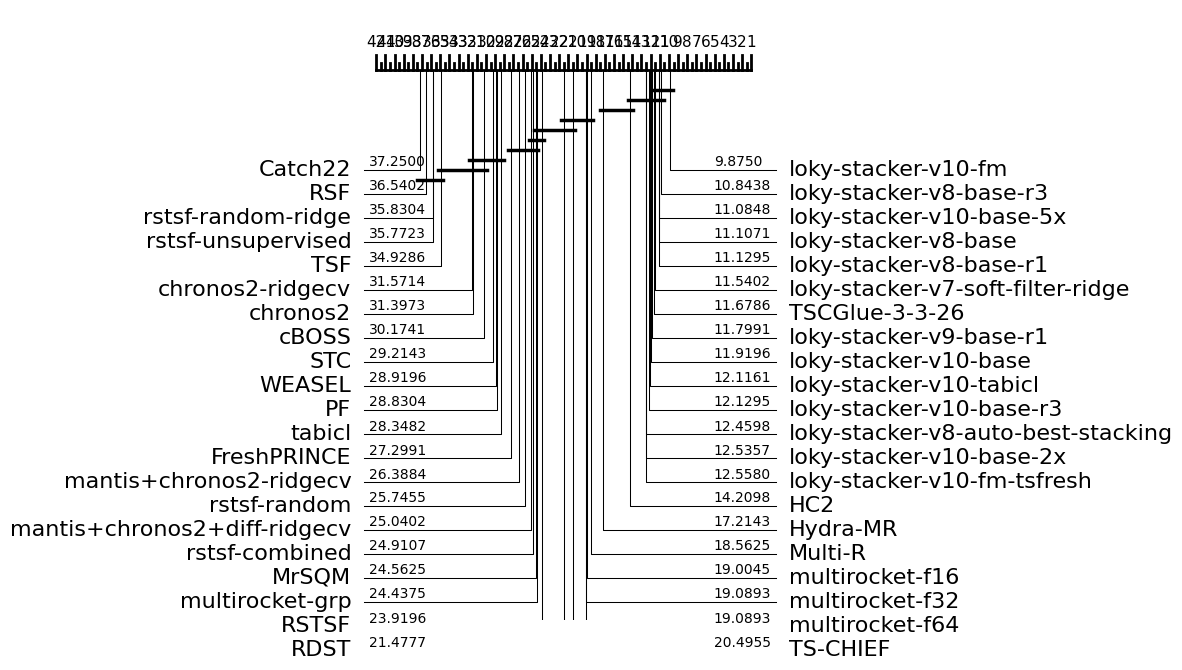

In [15]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

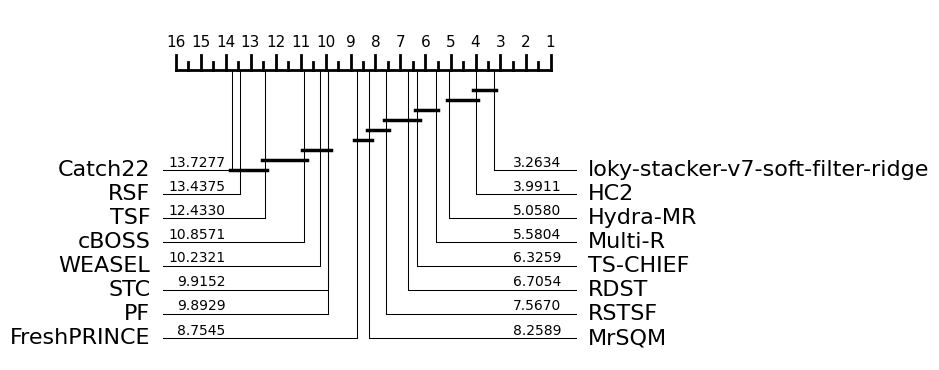

In [16]:
clsf = df_performance_full.select([
    c for c in df_performance_full.columns if c != "dataset" and (c in classifiers or c == 'loky-stacker-v7-soft-filter-ridge')
])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches='tight', pad_inches=0)


In [17]:
clsf

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,loky-stacker-v7-soft-filter-ridge
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.886538,0.870513,0.979327,0.926923,0.973878,0.926603,0.715705,0.932372,0.801603,0.865865,0.908333,0.96891,0.392468,0.978365,0.965705,0.935417
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,0.941667
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,0.783733
0.591197,0.726838,0.849915,0.844103,0.812308,0.844017,0.799829,0.847094,0.707778,0.773077,0.774359,0.817009,0.701368,0.792564,0.745726,0.858205
0.677218,0.698561,0.707434,0.695923,0.677938,0.694964,0.692086,0.705276,0.669065,0.694005,0.694964,0.691847,0.688729,0.689688,0.678897,0.703118
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.820029,0.854386,0.954532,0.931433,0.954825,0.928509,0.835526,0.949123,0.905848,0.873099,0.95,0.959795,0.661257,0.940497,0.940351,0.947368
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,1.0
0.880093,0.982407,0.987731,0.985185,0.91713,0.980093,0.954398,0.974769,0.727546,0.959491,0.926157,0.983333,0.806944,0.969907,0.904398,0.987731


In [18]:
#clsf = df_performance_full.select(['loky-stacker-v6-soft-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
#plot_critical_difference(clsf.to_numpy(), clsf.columns)

(<Figure size 600x270 with 1 Axes>, <Axes: >)

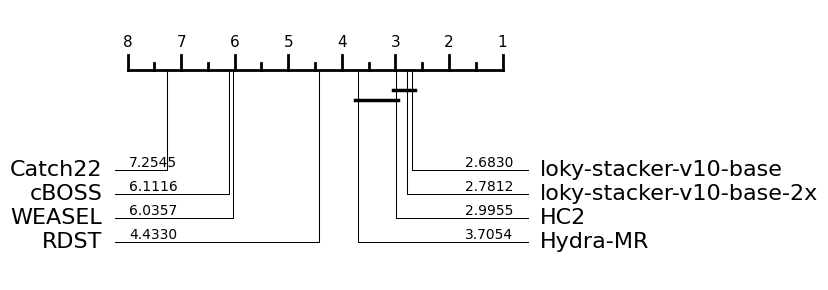

In [19]:
clsf = df_performance_full.select(['loky-stacker-v10-base', 'loky-stacker-v10-base-2x', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [20]:
df_performance_full

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,multirocket-f32,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multirocket-f16,loky-stacker-v10-fm,tabicl,multirocket-f64,loky-stacker-v8-base,rstsf-unsupervised,loky-stacker-v10-base,chronos2-ridgecv,loky-stacker-v8-base-r3,multirocket-grp,loky-stacker-v8-auto-best-stacking,chronos2,mantis+chronos2+diff-ridgecv,loky-stacker-v10-base-2x,mantis+chronos2-ridgecv,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,rstsf-combined,loky-stacker-v10-base-5x,TSCGlue-3-3-26,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.886538,0.870513,0.979327,0.926923,0.973878,0.926603,0.715705,0.932372,0.801603,0.865865,0.908333,0.96891,0.392468,0.978365,0.965705,"""PigArtPressure""",0.927724,0.935417,0.905449,0.935417,0.927724,0.935417,0.266722,0.927724,0.935417,0.596795,0.935417,0.412821,0.93563,0.920032,0.935417,0.415064,0.825,0.935417,0.688622,0.731731,0.935417,0.373878,0.759615,0.936174,0.935417,0.934776,0.930288
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.89,0.941667,0.931667,0.941667,0.89,0.961667,0.726667,0.89,0.94,0.85,0.938333,0.95,0.927778,0.896667,0.94,0.95,0.961667,0.938333,0.973333,0.943333,0.941667,0.911667,0.964286,0.92931,0.936667,0.936667,0.928571
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,"""RefrigerationDevices""",0.734489,0.783822,0.783022,0.786489,0.733956,0.786578,0.554667,0.734489,0.784089,0.664889,0.783911,0.670489,0.784,0.719556,0.779911,0.669091,0.722311,0.7856,0.724622,0.751733,0.783733,0.553511,0.753185,0.7864,0.784,0.780622,0.767619
0.591197,0.726838,0.849915,0.844103,0.812308,0.844017,0.799829,0.847094,0.707778,0.773077,0.774359,0.817009,0.701368,0.792564,0.745726,"""CricketY""",0.842479,0.858205,0.857863,0.857436,0.842479,0.859402,0.676923,0.842479,0.858291,0.671282,0.85641,0.708205,0.860181,0.831795,0.854103,0.717521,0.787094,0.857436,0.778291,0.760085,0.858205,0.633077,0.763004,0.856145,0.858974,0.857094,0.855556
0.677218,0.698561,0.707434,0.695923,0.677938,0.694964,0.692086,0.705276,0.669065,0.694005,0.694964,0.691847,0.688729,0.689688,0.678897,"""DistalPhalanxTW""",0.697842,0.702398,0.703597,0.719664,0.698321,0.708153,0.704556,0.697842,0.702398,0.68303,0.703837,0.675779,0.702638,0.695444,0.702878,0.675278,0.680336,0.702398,0.6753,0.679616,0.703118,0.670024,0.688399,0.704044,0.702158,0.704556,0.719424
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.820029,0.854386,0.954532,0.931433,0.954825,0.928509,0.835526,0.949123,0.905848,0.873099,0.95,0.959795,0.661257,0.940497,0.940351,"""ToeSegmentation1""",0.927047,0.947515,0.947515,0.94152,0.927047,0.958333,0.64152,0.927047,0.947515,0.9033,0.948977,0.907602,0.947599,0.926316,0.948099,0.90873,0.951608,0.946784,0.950731,0.87076,0.947368,0.883187,0.89364,0.949788,0.947953,0.947368,0.962719
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",0.996252,1.0,1.0,1.0,0.996252,1.0,1.0,0.996252,1.0,0.988526,1.0,0.857697,1.0,0.990897,1.0,0.858381,0.987015,1.0,0.994244,1.0,1.0,0.999197,1.0,1.0,1.0,1.0,1.0
0.880093,0.982407,0.987731,0.985185,0.91713,0.980093,0.954398,0.974769,0.727546,0.959491,0.926157,0.983333,0.806944,0.969907,0.904398,"""UMD""",0.981481,0.98912,0.987963,0.987037,0.981481,0.991667,0.978241,0.981481,0.98912,0.844907,0.988194,0.994213,0.986742,0.979861,0.988426,0.994263,0.992824,0.988426,0.995139,0.948148,0.987731,0.913657,0.925347,0.988506,0.989815,0.987731,0.986111


(<Figure size 600x260 with 1 Axes>, <Axes: >)

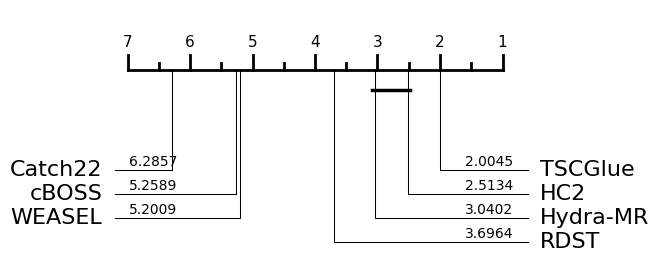

In [21]:
clsf = df_performance_full.rename({'loky-stacker-v10-fm': 'TSCGlue'}).select(['TSCGlue', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [22]:
v = (df_performance_full['loky-stacker-v10-base-2x'] - df_performance_full['HC2']).to_numpy()
(v>0).sum(), (v<0).sum(), (v==0).sum()

(np.int64(60), np.int64(48), np.int64(4))

In [23]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,multirocket-f32,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v10-tabicl,multirocket-f16,loky-stacker-v10-fm,tabicl,multirocket-f64,loky-stacker-v8-base,rstsf-unsupervised,loky-stacker-v10-base,chronos2-ridgecv,loky-stacker-v8-base-r3,multirocket-grp,loky-stacker-v8-auto-best-stacking,chronos2,mantis+chronos2+diff-ridgecv,loky-stacker-v10-base-2x,mantis+chronos2-ridgecv,rstsf-random,loky-stacker-v7-soft-filter-ridge,rstsf-random-ridge,rstsf-combined,loky-stacker-v10-base-5x,TSCGlue-3-3-26,loky-stacker-v9-base-r1,loky-stacker-v10-fm-tsfresh,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.952397,0.952179,0.952179,0.952179,0.952397,0.952179,0.964706,0.952397,0.952179,0.919432,0.952179,0.959368,0.952692,0.950327,0.952179,0.954902,0.957081,0.952179,0.959477,0.944444,0.952179,0.912092,0.942662,0.952896,0.952179,0.952179,0.964597,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",0.996252,1.0,1.0,1.0,0.996252,1.0,1.0,0.996252,1.0,0.988526,1.0,0.857697,1.0,0.990897,1.0,0.858381,0.987015,1.0,0.994244,1.0,1.0,0.999197,1.0,1.0,1.0,1.0,1.0,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.9,0.895,0.91,0.883333,0.9,0.908333,0.753333,0.9,0.895,0.879545,0.901667,0.833333,0.897619,0.9,0.903333,0.826316,0.905,0.896667,0.891667,0.885,0.895,0.846667,0.885,0.901667,0.895,0.906667,0.871429,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.89,0.941667,0.931667,0.941667,0.89,0.961667,0.726667,0.89,0.94,0.85,0.938333,0.95,0.927778,0.896667,0.94,0.95,0.961667,0.938333,0.973333,0.943333,0.941667,0.911667,0.964286,0.92931,0.936667,0.936667,0.928571,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.966667,0.975607,0.974927,0.973081,0.966667,0.974927,0.972886,0.966667,0.975607,0.945374,0.973761,0.971914,0.976433,0.86482,0.974344,0.975948,0.965015,0.974344,0.969679,0.976579,0.97551,0.959086,0.974821,0.973567,0.975802,0.974733,0.971574,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.855245,0.862626,0.862626,0.864569,0.855439,0.863403,0.868221,0.855245,0.862937,0.779598,0.863287,0.815695,0.865708,0.832906,0.861772,0.818334,0.831352,0.864763,0.822688,0.841647,0.862587,0.809207,0.833333,0.862557,0.862937,0.863015,0.862138,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.953737,0.981439,0.981136,0.985328,0.953813,0.981389,0.902525,0.953737,0.981465,0.937689,0.981338,0.930732,0.981402,0.927904,0.984571,0.93024,0.949571,0.981034,0.940455,0.977803,0.981414,0.982247,0.98266,0.98193,0.981414,0.981237,1.0,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.92823,0.9407,0.939959,0.940864,0.928148,0.939588,0.862757,0.92823,0.940741,0.913653,0.940535,0.911934,0.945385,0.895967,0.939547,0.910617,0.91963,0.941209,0.914074,0.920988,0.940741,0.920741,0.928395,0.94127,0.940453,0.940206,0.931893

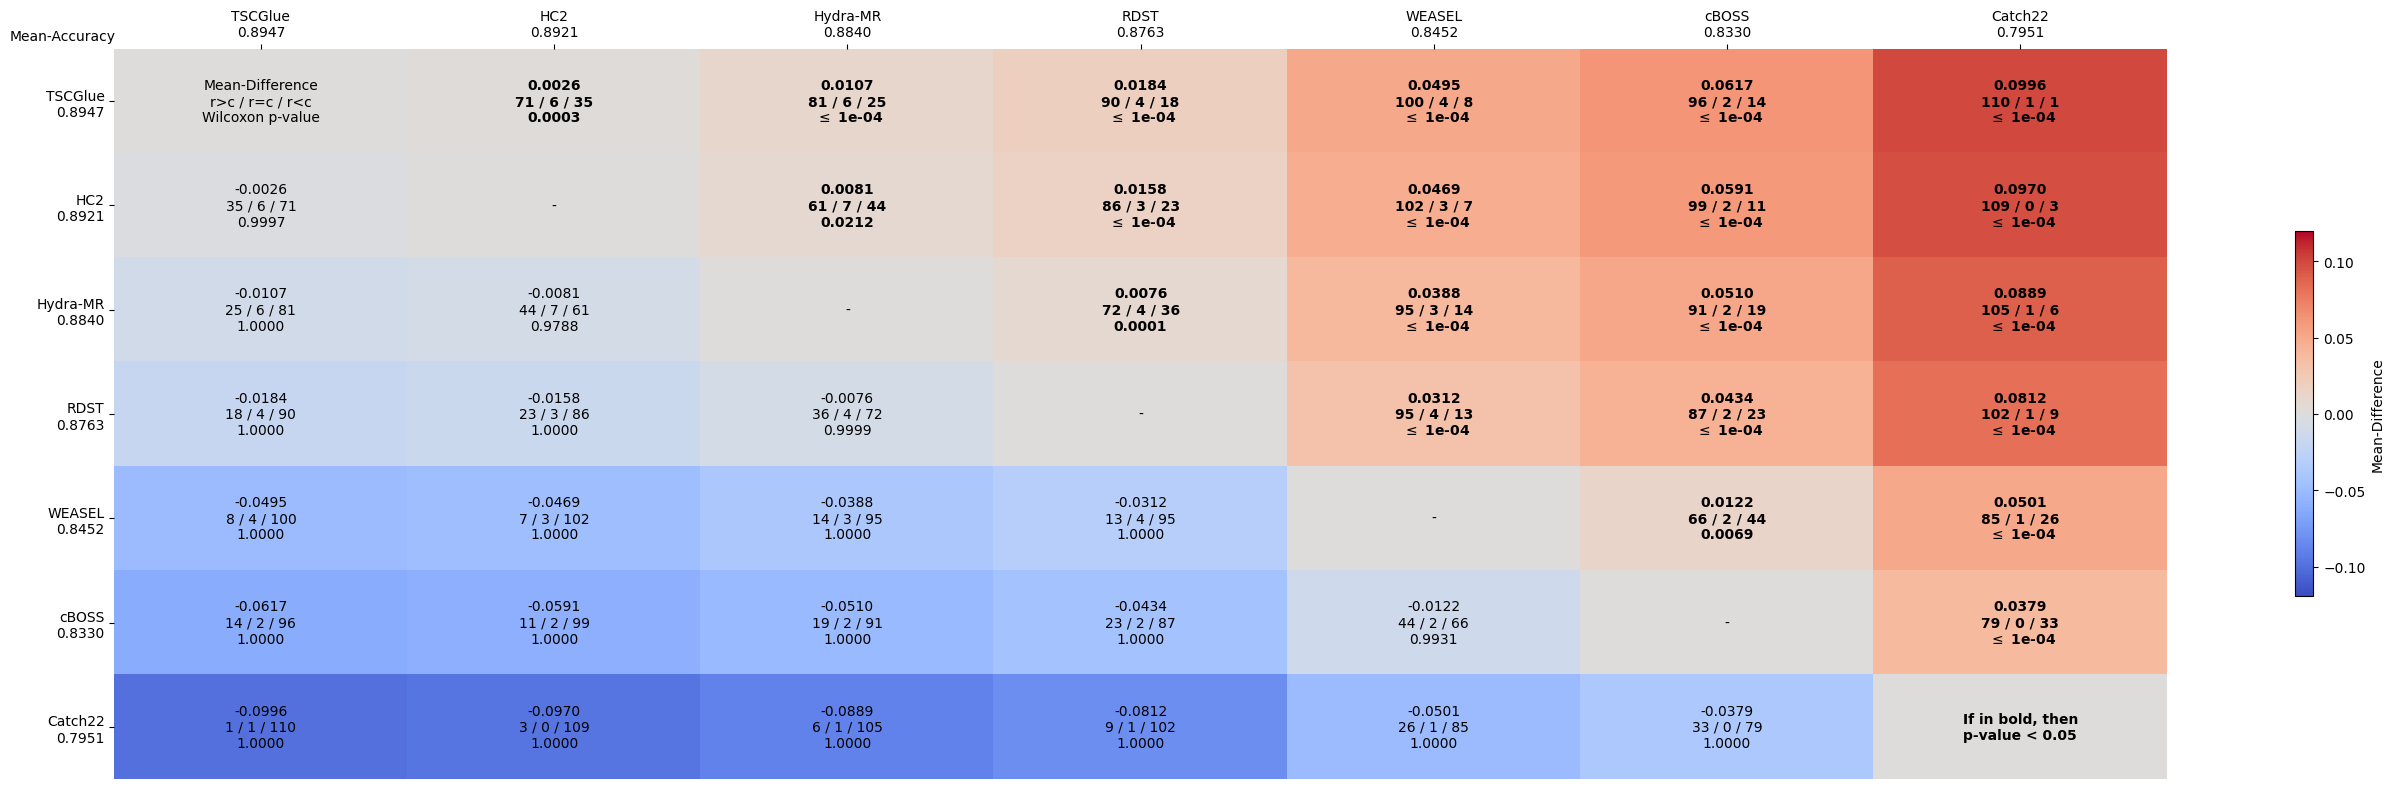

In [24]:
from aeon.visualisation import create_multi_comparison_matrix

create_multi_comparison_matrix(clsf.to_pandas())
plt.savefig(f"{directory}/multi_comparison_matrix.pdf", bbox_inches='tight', pad_inches=0)

In [25]:
def plot_acc_diff_vs_size(df, m1, m2):
    data = df.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
    plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
    plt.xlabel('Training Set Size')
    plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
    plt.xscale('log')
    plt.grid()
    plt.axhline(0, color='black', linewidth=0.8)
    ylim = plt.gca().get_ylim()
    plt.axhspan(0, ylim[1], alpha=0.08, color='green')
    plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
    plt.text(0.98, 0.95, f'{m1} better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
    plt.text(0.98, 0.05, f'{m2} better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
    plt.ylim(ylim)


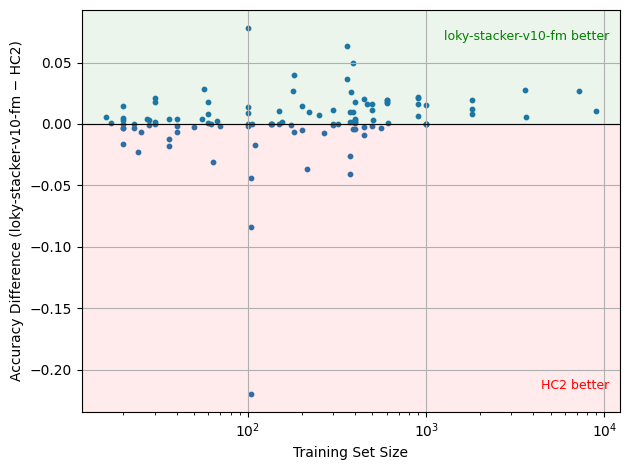

In [26]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-fm', 'HC2')


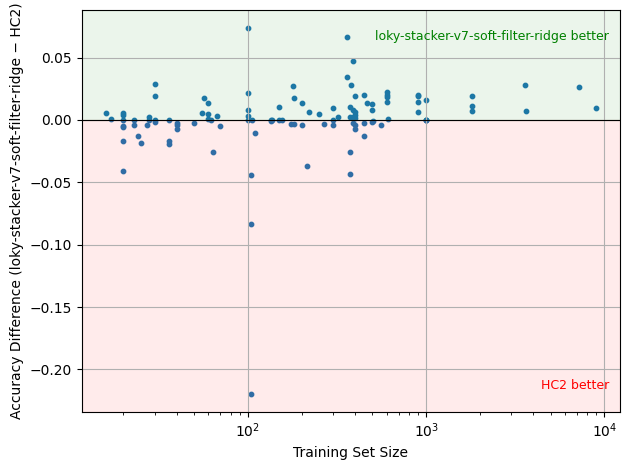

In [27]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-filter-ridge', 'HC2')

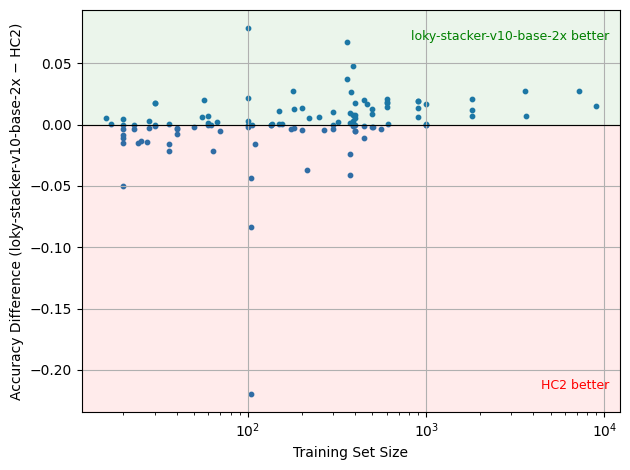

In [28]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-base-2x', 'HC2')


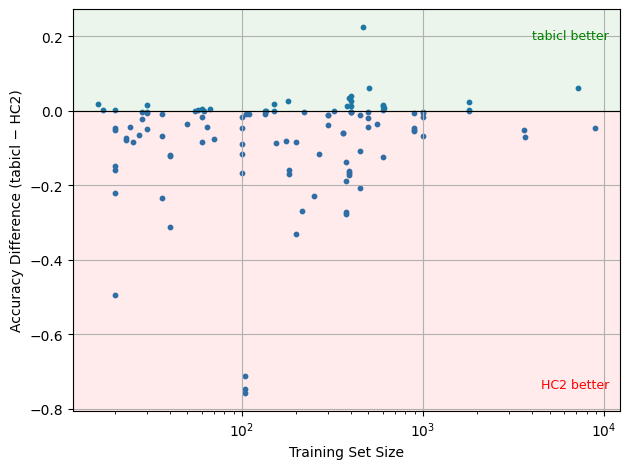

In [29]:
plot_acc_diff_vs_size(df_performance_full, 'tabicl', 'HC2')


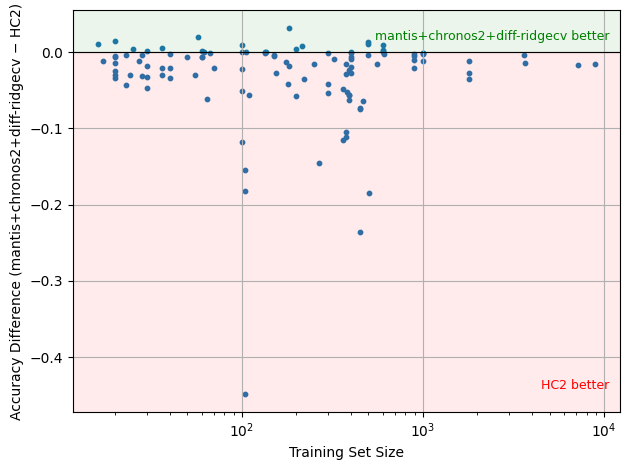

In [30]:
plot_acc_diff_vs_size(df_performance_full, 'mantis+chronos2+diff-ridgecv', 'HC2')

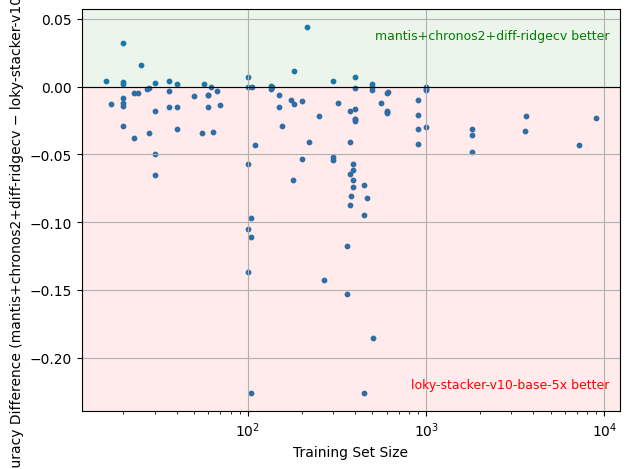

In [31]:
plot_acc_diff_vs_size(df_performance_full, 'mantis+chronos2+diff-ridgecv', 'loky-stacker-v10-base-5x')

In [32]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-ridge', 'loky-stacker-v7-soft-rf')

ColumnNotFoundError: "loky-stacker-v7-soft-ridge" not found

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-ridge', 'loky-stacker-v7-soft-et')

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-rf', 'loky-stacker-v7-soft-et')

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v8-auto-best', 'loky-stacker-v8-base')


In [ ]:
res_mine_f0 = res_mine.filter(pl.col('fold')==0)